# Irembo Voice AI - Exploratory Data Analysis

This notebook provides comprehensive analysis of the Irembo Voice AI intent classification dataset, including:
- Dataset statistics and distribution
- Language composition analysis
- Intent distribution visualization
- Model performance comparison

**Dataset**: Kinyarwanda/English code-switched utterances for government e-service intents

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set(style='white')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Data Paths
DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'

## Load Dataset

In [24]:
train_df = pd.read_csv(DATA_DIR / 'voiceai_intent_train.csv')
val_df = pd.read_csv(DATA_DIR / 'voiceai_intent_val.csv')
test_df = pd.read_csv(DATA_DIR / 'voiceai_intent_test.csv')

train_df['split'] = 'train'
val_df['split'] = 'validation'
test_df['split'] = 'test'
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Rename column for convenience
# full_df['text'] = full_df['utterance_text']

print(f"Dataset Summary:")
print(f"   Train:      {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test:       {len(test_df):,} samples")
print(f"   Total:      {len(full_df):,} samples")
print(f"\nColumns: {list(full_df.columns)}")

Dataset Summary:
   Train:      561 samples
   Validation: 70 samples
   Test:       69 samples
   Total:      700 samples

Columns: ['utterance_id', 'timestamp', 'channel', 'device_type', 'region', 'language', 'utterance_text', 'asr_confidence', 'duration_seconds', 'intent', 'split']


In [27]:
full_df.head(10)

,utterance_id,timestamp,channel,device_type,region,language,utterance_text,asr_confidence,duration_seconds,intent,split
0,utt_00159,2025-11-07T15:32:00,whatsapp_voice_note,feature_phone,Western,en,What are the requirements for ID replacement?,0.902,9,requirements_information,train
1,utt_00501,2025-11-12T10:41:00,voice_call,android,Kigali,en,Am I eligible to apply for ESIA?,0.644,7,service_eligibility,train
2,utt_00397,2025-11-28T17:58:00,ivr,web,Eastern,mixed,Help me reset password yanjye.,0.964,9,reset_password_login_help,train
3,utt_00156,2025-11-25T19:52:00,voice_call,web,Southern,en,I submitted my aplikasiyo but I can't see the ...,0.911,2,check_application_status,train
4,utt_00322,2025-11-24T00:46:00,voice_call,feature_phone,Eastern,en,I want to start a new application for birth ce...,0.810,10,start_new_application,train
5,utt_00213,2025-11-06T23:34:00,mobile_app_voice,android,Eastern,en,What are the requirements for ESIA?,0.942,7,requirements_information,train
6,utt_00235,2025-11-22T09:16:00,voice_call,web,Eastern,en,What are the requirements for driving license?,0.881,7,requirements_information,train
7,utt_00290,2025-11-24T21:29:00,voice_call,ios,Western,en,I paid but it is not confirmed.,0.814,7,payment_help,train
8,utt_00301,2025-10-13T01:54:00,voice_call,feature_phone,Kigali,en,Am I eligible to apply for driving license?,0.821,9,service_eligibility,train
9,utt_00357,2025-12-07T16:36:00,whatsapp_voice_note,ios,Kigali,rw,"Nshaka gusaba attestation y’imisoro, ntangira he?",0.823,4,start_new_application,train


In [31]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   utterance_id      700 non-null    object 
 1   timestamp         700 non-null    object 
 2   channel           700 non-null    object 
 3   device_type       700 non-null    object 
 4   region            700 non-null    object 
 5   language          700 non-null    object 
 6   utterance_text    700 non-null    object 
 7   asr_confidence    700 non-null    float64
 8   duration_seconds  700 non-null    int64  
 9   intent            700 non-null    object 
 10  split             700 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 60.3+ KB


## Intent Distribution Analysis

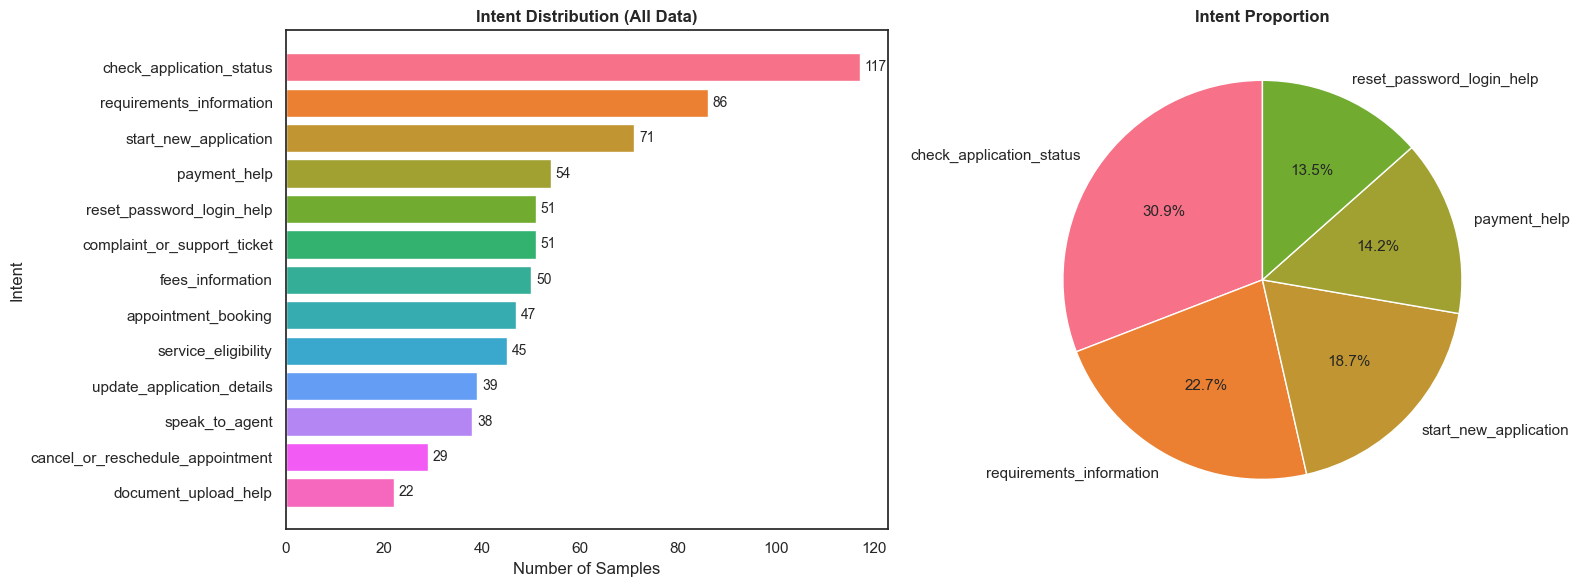

In [41]:
intent_counts = full_df['intent'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1 = axes[0]
colors = sns.color_palette('husl', len(intent_counts))
bars = ax1.barh(intent_counts.index, intent_counts.values, color=colors)
ax1.set_xlabel('Number of Samples')
ax1.set_ylabel('Intent')
ax1.set_title('Intent Distribution (All Data)', fontweight='bold')
ax1.invert_yaxis()

for bar, count in zip(bars, intent_counts.values):
    ax1.text(count + 1, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=10)

ax2 = axes[1]
ax2.pie(intent_counts.values.tolist()[:5], labels=intent_counts.index.tolist()[:5], autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Intent Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/intent_distribution.png', dpi=150, bbox_inches='tight')
plt.show();

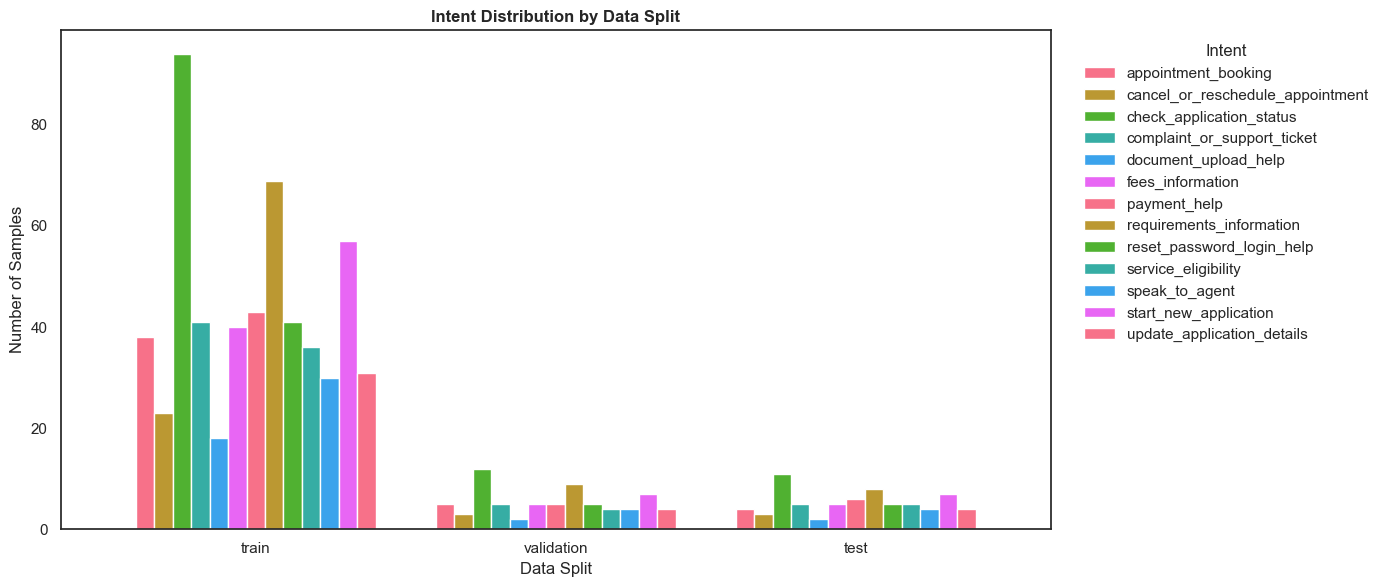

In [42]:
split_intent = full_df.groupby(['split', 'intent']).size().unstack(fill_value=0)
split_intent = split_intent.reindex(['train', 'validation', 'test'])

fig, ax = plt.subplots(figsize=(14, 6))
split_intent.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Data Split')
ax.set_ylabel('Number of Samples')
ax.set_title('Intent Distribution by Data Split', fontweight='bold')
ax.legend(title='Intent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/intent_by_split.png', dpi=150, bbox_inches='tight')
plt.show();

## Language Distribution Analysis

In [43]:
full_df.head()

,utterance_id,timestamp,channel,device_type,region,language,utterance_text,asr_confidence,duration_seconds,intent,split
0,utt_00159,2025-11-07T15:32:00,whatsapp_voice_note,feature_phone,Western,en,What are the requirements for ID replacement?,0.902,9,requirements_information,train
1,utt_00501,2025-11-12T10:41:00,voice_call,android,Kigali,en,Am I eligible to apply for ESIA?,0.644,7,service_eligibility,train
2,utt_00397,2025-11-28T17:58:00,ivr,web,Eastern,mixed,Help me reset password yanjye.,0.964,9,reset_password_login_help,train
3,utt_00156,2025-11-25T19:52:00,voice_call,web,Southern,en,I submitted my aplikasiyo but I can't see the ...,0.911,2,check_application_status,train
4,utt_00322,2025-11-24T00:46:00,voice_call,feature_phone,Eastern,en,I want to start a new application for birth ce...,0.810,10,start_new_application,train


/var/folders/_d/4hnhwqd50ks5c10l89lqw1k80000gn/T/ipykernel_71738/1883310487.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([lang_labels.get(l, l) for l in lang_counts.index])


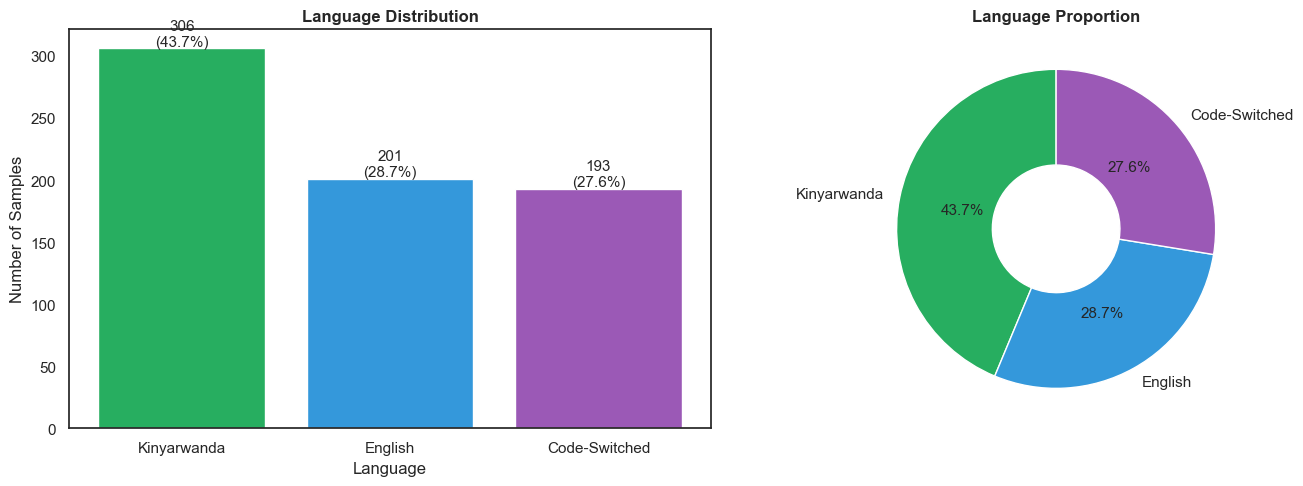

In [44]:
lang_counts = full_df['language'].value_counts()
lang_labels = {'en': 'English', 'rw': 'Kinyarwanda', 'mixed': 'Code-Switched'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_lang = {'en': '#3498db', 'rw': '#27ae60', 'mixed': '#9b59b6'}
ax1 = axes[0]
bars = ax1.bar(lang_counts.index, lang_counts.values,
               color=[colors_lang.get(l, '#95a5a6') for l in lang_counts.index])
ax1.set_xlabel('Language')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Language Distribution', fontweight='bold')

ax1.set_xticklabels([lang_labels.get(l, l) for l in lang_counts.index])

for bar, count in zip(bars, lang_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, count + 2,
             f'{count}\n({count/len(full_df)*100:.1f}%)',
             ha='center', fontsize=11)
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    lang_counts.values,
    labels=[lang_labels.get(l, l) for l in lang_counts.index],
    autopct='%1.1f%%',
    colors=[colors_lang.get(l, '#95a5a6') for l in lang_counts.index],
    wedgeprops=dict(width=0.6),
    startangle=90
)
ax2.set_title('Language Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
print(f"Language Statistics:")
for lang, count in lang_counts.items():
    print(f"   {lang_labels.get(lang, lang)}: {count} ({count/len(full_df)*100:.1f}%)")

Language Statistics:
   Kinyarwanda: 306 (43.7%)
   English: 201 (28.7%)
   Code-Switched: 193 (27.6%)


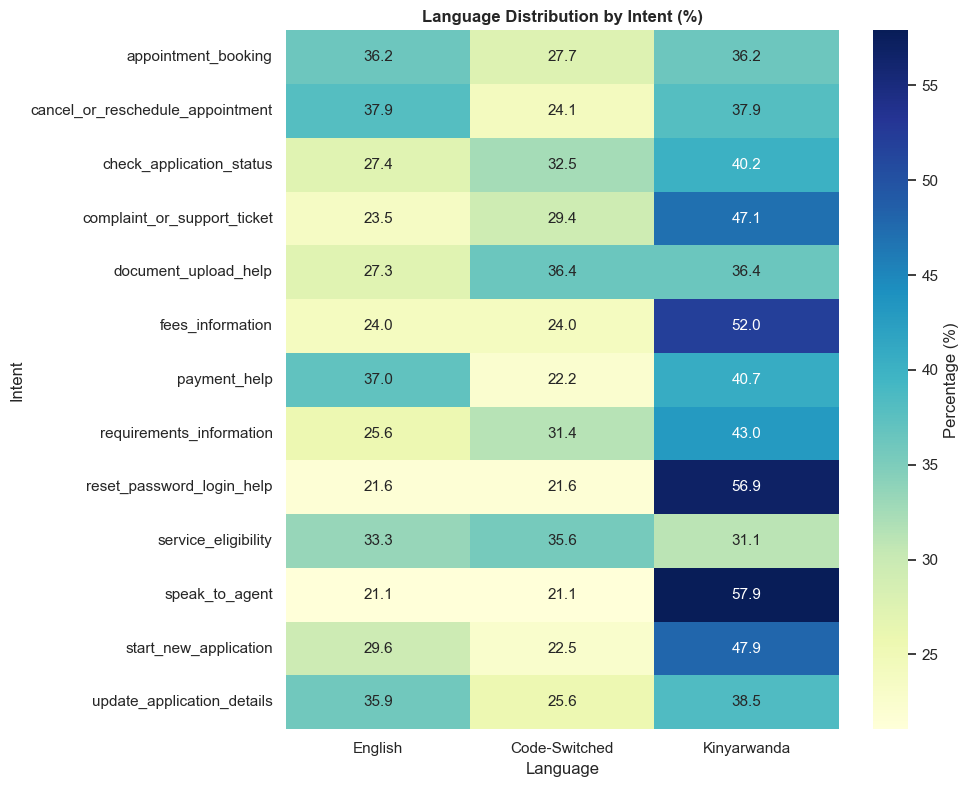

In [46]:
# Language distribution by intent
lang_intent = pd.crosstab(full_df['intent'], full_df['language'], normalize='index') * 100
lang_labels = {'en': 'English', 'rw': 'Kinyarwanda', 'mixed': 'Code-Switched'}
lang_intent.columns = [lang_labels.get(c, c) for c in lang_intent.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(lang_intent, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title('Language Distribution by Intent (%)', fontweight='bold')
ax.set_xlabel('Language')
ax.set_ylabel('Intent')

plt.tight_layout()
plt.savefig('../reports/figures/language_by_intent_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Text Length Analysis

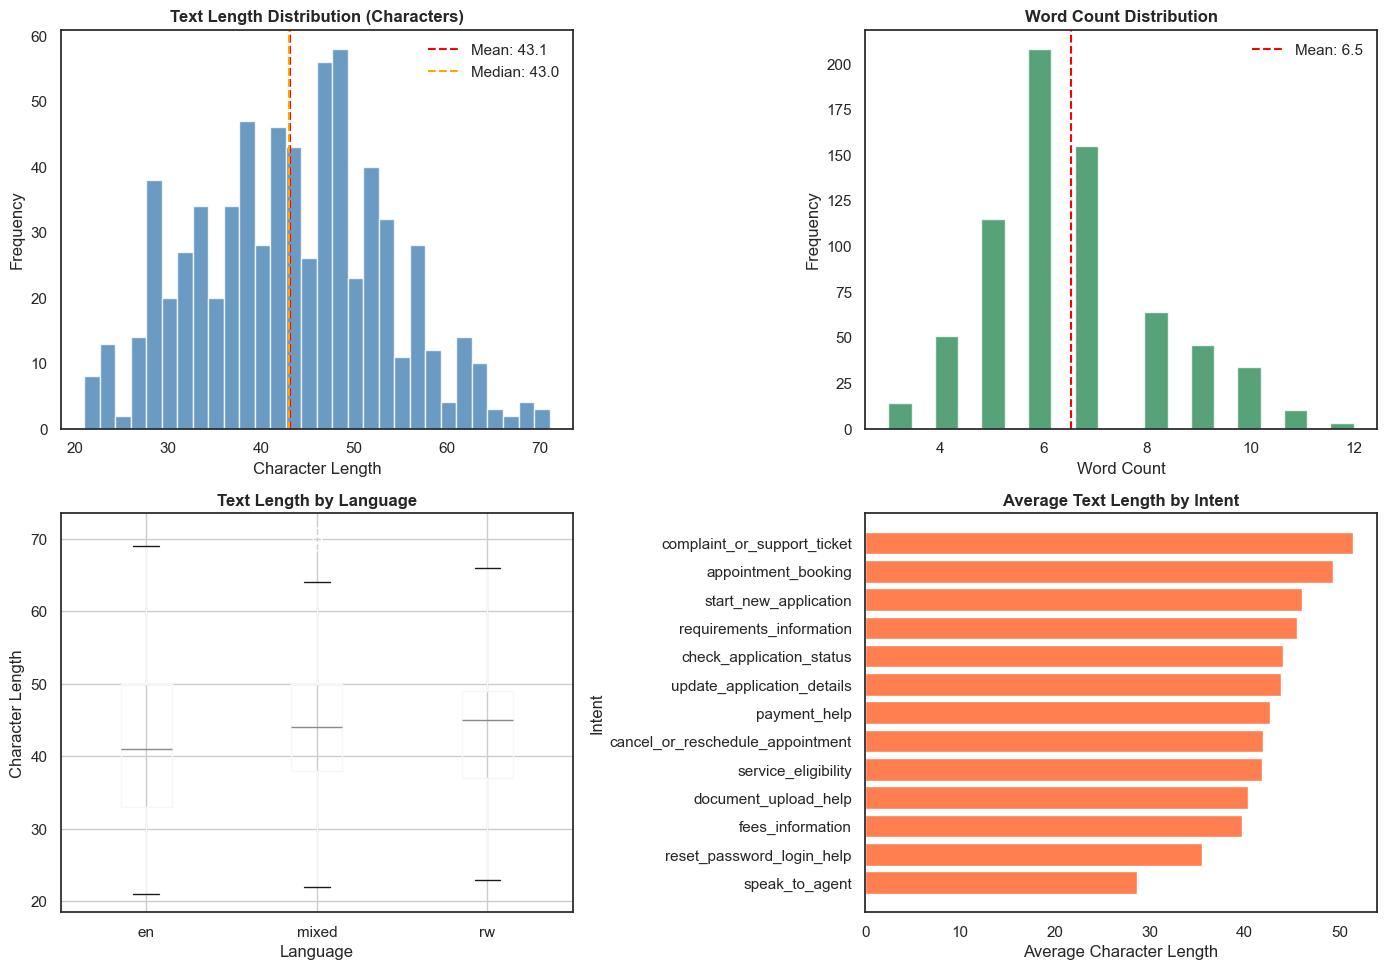

In [49]:
# text lengths
full_df['text_length'] = full_df['utterance_text'].str.len()
full_df['word_count'] = full_df['utterance_text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# length distribution
ax1 = axes[0, 0]
ax1.hist(full_df['text_length'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(full_df['text_length'].mean(), color='red', linestyle='--',
            label=f'Mean: {full_df["text_length"].mean():.1f}')
ax1.axvline(full_df['text_length'].median(), color='orange', linestyle='--',
            label=f'Median: {full_df["text_length"].median():.1f}')
ax1.set_xlabel('Character Length')
ax1.set_ylabel('Frequency')
ax1.set_title('Text Length Distribution (Characters)', fontweight='bold')
ax1.legend()

# Word count
ax2 = axes[0, 1]
ax2.hist(full_df['word_count'], bins=20, color='seagreen', edgecolor='white', alpha=0.8)
ax2.axvline(full_df['word_count'].mean(), color='red', linestyle='--',
            label=f'Mean: {full_df["word_count"].mean():.1f}')
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Frequency')
ax2.set_title('Word Count Distribution', fontweight='bold')
ax2.legend()

# Length by language
ax3 = axes[1, 0]
full_df.boxplot(column='text_length', by='language', ax=ax3)
ax3.set_xlabel('Language')
ax3.set_ylabel('Character Length')
ax3.set_title('Text Length by Language', fontweight='bold')
plt.suptitle('')

# Length by intent
ax4 = axes[1, 1]
intent_lengths = full_df.groupby('intent')['text_length'].mean().sort_values(ascending=True)
ax4.barh(intent_lengths.index, intent_lengths.values, color='coral')
ax4.set_xlabel('Average Character Length')
ax4.set_ylabel('Intent')
ax4.set_title('Average Text Length by Intent', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
print(f"\nText Statistics:")
print(f"   Avg. characters: {full_df['text_length'].mean():.1f}")
print(f"   Avg. words:      {full_df['word_count'].mean():.1f}")
print(f"   Min length:      {full_df['text_length'].min()} chars")
print(f"   Max length:      {full_df['text_length'].max()} chars")


Text Statistics:
   Avg. characters: 43.1
   Avg. words:      6.5
   Min length:      21 chars
   Max length:      71 chars


## Model Performance Comparison

In [51]:
# Model results
results = {
    'Model': ['Rule-Based Baseline', 'AfroXLMR-base (Tuned)'],
    'Accuracy': [88.41, 95.65],
    'Macro F1': [0.8937, 0.9563],
    'Macro Precision': [0.9034, 0.9654],
    'Macro Recall': [0.8857, 0.9526],
    'Latency (ms)': [0.02, 75]
}

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)

print("Model Performance Summary:")
display(results_df)

Model Performance Summary:


,Accuracy,Macro F1,Macro Precision,Macro Recall,Latency (ms)
Model,,,,,
Rule-Based Baseline,88.41,0.8937,0.9034,0.8857,0.02
AfroXLMR-base (Tuned),95.65,0.9563,0.9654,0.9526,75.00


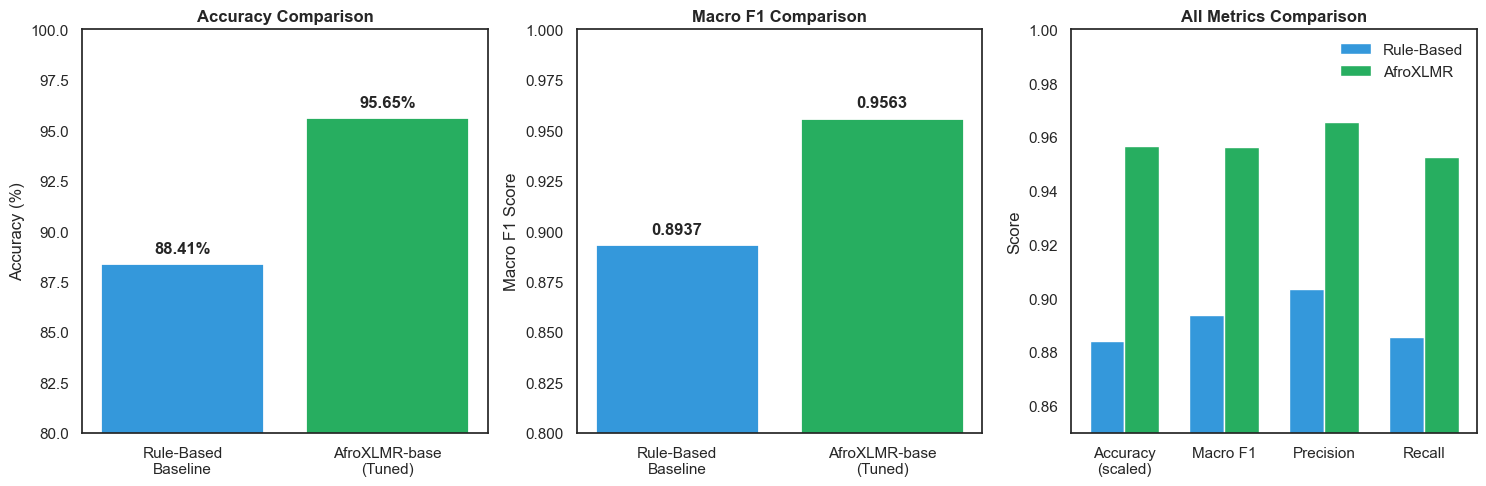

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Rule-Based\nBaseline', 'AfroXLMR-base\n(Tuned)']
colors = ['#3498db', '#27ae60']

# Accuracy comparison
ax1 = axes[0]
bars = ax1.bar(models, results['Accuracy'], color=colors, edgecolor='white', linewidth=2)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylim(80, 100)
for bar, acc in zip(bars, results['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.5, f'{acc:.2f}%',
             ha='center', fontsize=12, fontweight='bold')

# F1 Score comparison
ax2 = axes[1]
bars = ax2.bar(models, results['Macro F1'], color=colors, edgecolor='white', linewidth=2)
ax2.set_ylabel('Macro F1 Score')
ax2.set_title('Macro F1 Comparison', fontweight='bold')
ax2.set_ylim(0.8, 1.0)
for bar, f1 in zip(bars, results['Macro F1']):
    ax2.text(bar.get_x() + bar.get_width()/2, f1 + 0.005, f'{f1:.4f}',
             ha='center', fontsize=12, fontweight='bold')

# All metrics comparison
ax3 = axes[2]
metrics = ['Accuracy\n(scaled)', 'Macro F1', 'Precision', 'Recall']
baseline_scores = [results['Accuracy'][0]/100, results['Macro F1'][0],
                   results['Macro Precision'][0], results['Macro Recall'][0]]
transformer_scores = [results['Accuracy'][1]/100, results['Macro F1'][1],
                      results['Macro Precision'][1], results['Macro Recall'][1]]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax3.bar(x - width/2, baseline_scores, width, label='Rule-Based', color=colors[0])
bars2 = ax3.bar(x + width/2, transformer_scores, width, label='AfroXLMR', color=colors[1])

ax3.set_ylabel('Score')
ax3.set_title('All Metrics Comparison', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.set_ylim(0.85, 1.0)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

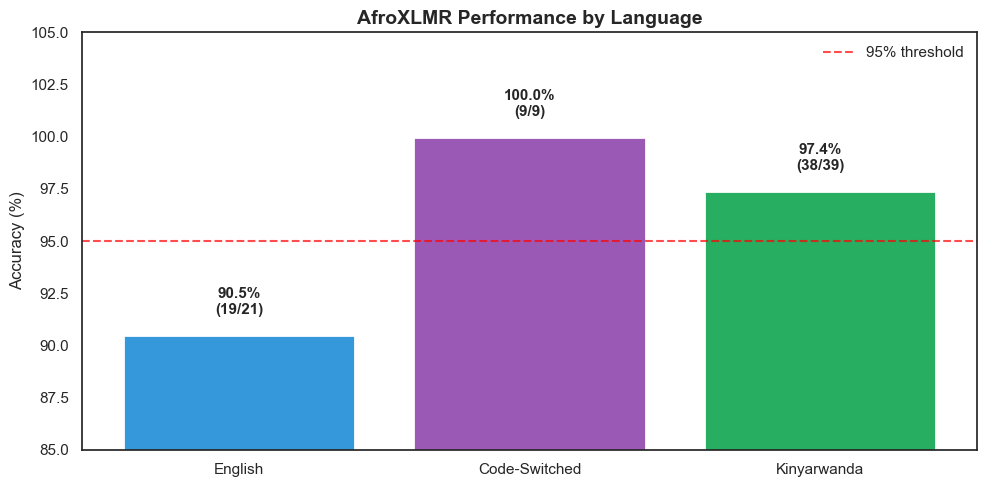

In [53]:
# Per-language performance (Transformer only)
lang_perf = {
    'Language': ['English', 'Code-Switched', 'Kinyarwanda'],
    'Correct': [19, 9, 38],
    'Total': [21, 9, 39],
    'Accuracy': [90.5, 100.0, 97.4]
}

lang_perf_df = pd.DataFrame(lang_perf)

fig, ax = plt.subplots(figsize=(10, 5))
colors_perf = ['#3498db', '#9b59b6', '#27ae60']
bars = ax.bar(lang_perf_df['Language'], lang_perf_df['Accuracy'],
              color=colors_perf, edgecolor='white', linewidth=2)

ax.set_ylabel('Accuracy (%)')
ax.set_title('AfroXLMR Performance by Language', fontweight='bold', fontsize=14)
ax.set_ylim(85, 105)

for bar, row in zip(bars, lang_perf_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, row.Accuracy + 1,
            f'{row.Accuracy:.1f}%\n({row.Correct}/{row.Total})',
            ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/transformer_by_language.png', dpi=150, bbox_inches='tight')
plt.show()

## Sample Utterances Analysis

In [55]:
print("Sample Utterances by Intent:\n")
for intent in sorted(full_df['intent'].unique())[:5]:
    intent_data = full_df[full_df['intent'] == intent]
    samples = intent_data.sample(min(2, len(intent_data)))
    print(f"\n{intent.upper()}")
    for _, row in samples.iterrows():
        print(f"   [{row['language']}] {row['utterance_text'][:80]}..." if len(row['utterance_text']) > 80 else f"   [{row['language']}] {row['utterance_text']}")

Sample Utterances by Intent:


APPOINTMENT_BOOKING
   [rw] Nashaka gufata appointment kuri pasiporo i Nyagatare.
   [rw] Nashaka gufata appointment kuri ESIA i Kicukiro.

CANCEL_OR_RESCHEDULE_APPOINTMENT
   [en] Can I change the appointment time?
   [mixed] Cancel appointment ya driving license please.

CHECK_APPLICATION_STATUS
   [mixed] Can you check status ya request yanjye?
   [rw] Checka niba application number yanjye yarangiye.

COMPLAINT_OR_SUPPORT_TICKET
   [mixed] Serivisi ya marriage certificate irimo ikibazo, help.
   [en] I want to raise a complaint about visa on arrival.

DOCUMENT_UPLOAD_HELP
   [en] How do I add documents to my application?
   [en] The attachment upload is failing.


In [56]:
def get_common_words(df, lang, n=10):
    texts = df[df['language'] == lang]['utterance_text'].str.lower()
    words = ' '.join(texts).split()
    # Remove very common words
    stopwords = {'i', 'my', 'the', 'to', 'a', 'is', 'for', 'and', 'of', 'can', 'you', 'how', 'do', 'what', 'need', 'want'}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

print("Most Common Words by Language:\n")

for lang, lang_name in [('en', 'English'), ('rw', 'Kinyarwanda'), ('mixed', 'Code-Switched')]:
    if lang in full_df['language'].values:
        common = get_common_words(full_df, lang)
        print(f"\n{lang_name}:")
        print(f"   {', '.join([f'{word} ({count})' for word, count in common])}")

Most Common Words by Language:


English:
   application (29), help (28), apply (22), appointment (21), driving (19), visa (16), are (15), payment (13), esia. (13), please (13)

Kinyarwanda:
   ndashaka (67), kuri (50), gusaba (41), nkeneye (38), yanjye. (30), aho (30), igeze. (30), nshaka (29), application (28), icyemezo (23)

Code-Switched:
   application (39), status (30), kuri (26), ndashaka (23), yanjye (19), nkeneye (18), help (17), documents (16), requirements (15), he? (15)


## Summary Statistics

In [58]:
print(f"\nDATASET STATISTICS")
print(f"   Total samples:      {len(full_df):,}")
print(f"   Train/Val/Test:     {len(train_df)}/{len(val_df)}/{len(test_df)}")
print(f"   Unique intents:     {full_df['intent'].nunique()}")
print(f"   Languages:          {', '.join(full_df['language'].unique())}")

print(f"\nLANGUAGE BREAKDOWN")
for lang in full_df['language'].unique():
    count = len(full_df[full_df['language'] == lang])
    pct = count / len(full_df) * 100
    lang_name = {'en': 'English', 'rw': 'Kinyarwanda', 'mixed': 'Code-Switched'}.get(lang, lang)
    print(f"   {lang_name}: {count} ({pct:.1f}%)")

print(f"\nMODEL PERFORMANCE (Test Set)")
print(f"   Rule-Based Baseline: 88.41% accuracy, 0.8937 F1")
print(f"   AfroXLMR-base:       95.65% accuracy, 0.9563 F1")
print(f"   Improvement:         +7.24% accuracy, +0.063 F1")

print(f"\nCONCLUSION")
print(f"   The fine-tuned AfroXLMR-base model achieves excellent performance")
print(f"   on Kinyarwanda/English intent classification, with particularly")
print(f"   strong results on code-switched (100%) and Kinyarwanda (97.4%)")
print(f"   utterances - key requirements for the Irembo Voice AI system.")


DATASET STATISTICS
   Total samples:      700
   Train/Val/Test:     561/70/69
   Unique intents:     13
   Languages:          en, mixed, rw

LANGUAGE BREAKDOWN
   English: 201 (28.7%)
   Code-Switched: 193 (27.6%)
   Kinyarwanda: 306 (43.7%)

MODEL PERFORMANCE (Test Set)
   Rule-Based Baseline: 88.41% accuracy, 0.8937 F1
   AfroXLMR-base:       95.65% accuracy, 0.9563 F1
   Improvement:         +7.24% accuracy, +0.063 F1

CONCLUSION
   The fine-tuned AfroXLMR-base model achieves excellent performance
   on Kinyarwanda/English intent classification, with particularly
   strong results on code-switched (100%) and Kinyarwanda (97.4%)
   utterances - key requirements for the Irembo Voice AI system.
